In [1]:
import numpy as np
import random
import matplotlib.pyplot as plt
import dask
from dask import delayed
from dask import bag as db
from sklearn.cluster import KMeans
import time

random.seed(42)

from sklearn.datasets import make_blobs # for local cluster generation only

In [2]:
# import the dask distributed client
from dask.distributed import Client

# instantiate the client by providing 
# the address:port of the scheduler
client = Client('dask-scheduler:8786')

# inspect the client
client

<Client: 'tcp://172.21.0.2:8786' processes=2 threads=2, memory=0.95 GiB>

In [3]:
data = make_blobs(n_samples=500, n_features=2, centers=4, random_state=42)
samples = data[0]

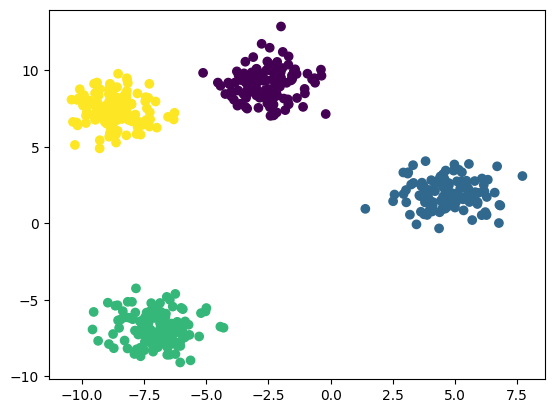

In [4]:
plt.scatter(samples[:,0], samples[:, 1], c=data[1])

In [5]:
X = db.from_sequence(data[0], npartitions=4)
client.persist(X) # (per partition) bc used at every iteration
x = data[0]
c = np.array([[0,0], [1, 1]])
centroids = c
dist_comp_times=0
min_dist_comp_times=0

In [6]:
class kmeans_parallel():
    def __init__(self, k, l):
        self.k = k
        self.l = l
        self.centroids = []

    def compute_all_distances(self, X): # expensive, do only once per iteration if possible
        centroids_arr = np.vstack(self.centroids)
        d2 = X.map(lambda x: np.linalg.norm(x - centroids_arr, axis=1) ** 2)
        global dist_comp_times # for analysis
        dist_comp_times=dist_comp_times+1
        return d2

    def compute_min_distances(self, X, distances=None): # to assign all points to closest centroid 
        if distances is None:
            distances= self.compute_all_distances(X)
        global min_dist_comp_times # for analysis
        min_dist_comp_times=min_dist_comp_times+1
        return distances.map(np.min)
 
    def cost_function(self, X, min_distances=None):
        if min_distances is None:
            min_distances= self.compute_min_distances(X)
        return min_distances.sum() # min + sum

    def compute_probabilities(self, X, l, distances=None, min_distances=None, cost=None):
        centroids_arr = np.vstack(self.centroids)
        if distances is None:
            d2 = self.compute_all_distances(X)
        else: d2=distances
        if min_distances is None:
            min_d2 = compute_min_distances(X, distances=d2) # min only
        else: min_d2=min_distances
        if cost is None:
            cost = self.cost_function(X, min_distances=min_d2)
        # clip to 1 so it's a valid Bernoulli probability
        prob = min_d2.map(lambda d: min(1.0, d * l / cost))
        return prob
    
    def compute_weigths(self, distances=None):
        centroids_arr = np.vstack(self.centroids)
        if distances is None:
            distances_from_centroids=self.compute_all_distances(X)
        else: distances_from_centroids = distances
        closer_centers_idxs = distances_from_centroids.map(lambda x: np.argmin(x))
        # the points in final set are few, can be stored on single machine
        return closer_centers_idxs.frequencies()

    def fit(self, X, alpha=1, l=1):
        ######################################################
        # STEP 1
        # Filter down to roughly 1% of the data randomly on workers, 
        # then take the first one that passes the test.
        initial_centroid = X.filter(lambda x: random.random() < 0.1).take(1)[0] # increased prob for small number of points
        # question: cant we just pick any?
        # is it really important that its drawn "uniformly at random" or is that said in step 1 to make things easier?
        initial_centroid = np.asarray(initial_centroid).reshape(1, -1)
        self.centroids.append(initial_centroid)

        ################################################
        # STEP 2
        psi = self.cost_function(X).compute()

        #####################################################
        # STEP 3
        max_iter = int(round(alpha * np.log(psi)))
        print("Number of planned iterations:", max_iter)

        for i in range(max_iter):
            dists=self.compute_all_distances(X)
            min_dists=self.compute_min_distances(X, distances=dists)
            dists, min_dists = dask.persist(dists, min_dists) 
            cost = self.cost_function(X, min_distances=min_dists).compute()
            probs = self.compute_probabilities(X, l, distances=dists, min_distances=min_dists, cost=cost)

            # sample directly in one lazy pass: pair each point with its prob,
            # keep it with probability prob, without a separate zip step
            paired = db.zip(X, probs)
            sample = (
                paired.filter(lambda t: np.random.uniform() < t[1])
                      .map(lambda t: t[0])
            )

            for s in sample:
                self.centroids.append(np.asarray(s).reshape(1, -1))

        ###################################################
        # STEP 7
        counts = np.array(self.compute_weigths().compute())
        weights = np.zeros(len(self.centroids))
        # create weights where each element correspond to 
        # centroids in self.centroids
        for center_idx, count in counts:
            weights[center_idx] = count

        centroids_weights =weights 

        ############################
        #########################
        # STEP 8 using scikit kmeans (few points, no need to parallize)

        kmeans = KMeans(n_clusters=self.k)
        kmeans.fit(np.vstack(self.centroids), sample_weight=centroids_weights)
        self.final_centroids = kmeans.cluster_centers_

        # ONLY STORED FOR ANALYSIS (DAG GRAPH)
        self.dists = dists
        self.min_dists = min_dists
        self.probs = probs

In [15]:
t1=time.time()
clf = kmeans_parallel(k=4, l=1)
clf.fit(X)
t2=time.time()
print("All distances computed in total", dist_comp_times, "times")
print("Min distances from centroids computed in total", min_dist_comp_times, "times")
print(f"Time elapsed: {t2-t1:.2f} s")
dist_comp_times=0
min_dist_comp_times=0

Number of planned iterations: 12
All distances computed in total 27 times
Min distances from centroids computed in total 25 times
Time elapsed: 5.12 s


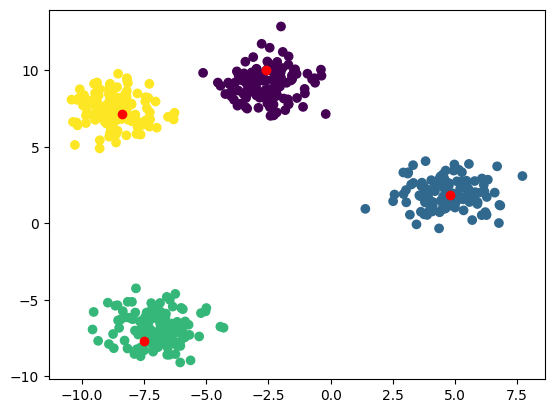

In [8]:
plt.scatter(samples[:,0], samples[:, 1], c=data[1])
plt.scatter(clf.final_centroids[:,0], clf.final_centroids[:,1], c="red")

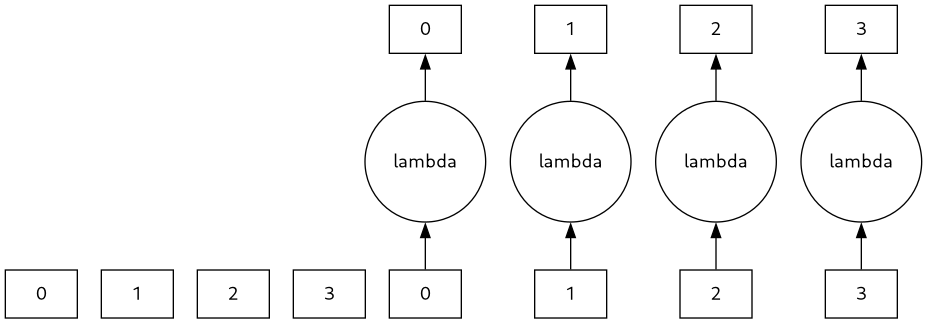

In [9]:
dask.visualize(clf.dists, clf.min_dists, clf.probs, optimize_graph=False, filename='dag_optimized.png')

In [10]:
# TODO: implement the rest of k means|| (ie, do standard k means with these initial centroids - 
# reuse these functions + assign point to closest centroid + update centroids + set a convergence criterion)